# SUMMARY

**Stack**: PyTorch, torchvision, Transformers, datasets, Pillow, numpy, matplotlib

**Description**: Solving the image caption task using EfficientNet + LSTM and EfficientNet + transformer combinations

* Data augmentation has been performed
* Learning the EfficientNet + LSTM model
* Learning the EfficientNet + transformer model

# Imports

In [1]:
!pip install pycocoevalcap
!pip install cider

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from torchvision.models import EfficientNet_B0_Weights

from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer

from PIL import Image
from datasets import Dataset, load_dataset, concatenate_datasets
from transformers import AutoProcessor, BlipForConditionalGeneration

INPUT_IMAGE_SIZE = (256, 256)
CROPPED_SIZE_IMAGE = (224, 224)

BATCH_SIZE = 64
NUM_WORKERS = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PROCESSOR_NAME = "Salesforce/blip-image-captioning-base"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 8.8 MB/s eta 0:00:00:00:0100:01
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


2025-10-16 19:13:43.496293: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760642023.741179      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760642023.808740      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load and preprocessing data

In [2]:
dataset = load_dataset("jxie/flickr8k")

README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [3]:
train_transform = v2.Compose([
    v2.Resize(INPUT_IMAGE_SIZE),
    v2.RandomResizedCrop(size=CROPPED_SIZE_IMAGE, antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.05
    )
    # v2.ToTensor(),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = v2.Compose([
    v2.Resize(CROPPED_SIZE_IMAGE)
    # v2.ToTensor(),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img_transform = v2.Compose([
    v2.ToTensor(),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

processor = AutoProcessor.from_pretrained(PROCESSOR_NAME)

/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [4]:
class ImageCaptionDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform, img_transform, processor, is_augment = False, augment_transform=None):
        self.processor = processor
        self.transform = transform
        self.img_transform = img_transform
        self.augment_transform = augment_transform
        self.is_augment = is_augment
        self.max_length = 32

        print("Start to make dataset")
        
        if is_augment:
            self.dataset = self.__augment_dataset(dataset)
        else:
            self.dataset = self.__test_dataset(dataset)

        print("Finished to make dataset")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        item = self.dataset[index]
        image = self.img_transform(item["image"])
        return image, item["caption"]

    def __augment_dataset(self, input_dataset):
        dataset = Dataset.from_dict({
            "image": input_dataset["image"],
            "caption": input_dataset["caption_0"]
        })

        processed_dataset = dataset.map(
            self.__make_test,
            batched=True,
            batch_size=128
        )

        augmented_dataset = dataset.map(
            self.__make_augment,
            batched=True,
            batch_size=128
        )

        return concatenate_datasets([processed_dataset, augmented_dataset])

    def __make_augment(self, dataset):
        return {
            "image": [self.augment_transform(img) for img in dataset["image"]],
            "caption": dataset["caption"]
        }

    def __test_dataset(self, input_dataset):
        dataset = Dataset.from_dict({
            "image": input_dataset["image"],
            "caption": input_dataset["caption_0"]
        })

        dataset = dataset.map(
            self.__make_test,
            batched=True,
            batch_size=128
        )

        return dataset

    def __make_test(self, dataset):
        return {
            "image": [self.transform(img) for img in dataset["image"]],
            "caption": dataset["caption"]
        }

In [5]:
# train_dataset = ImageCaptionDataset(
#     dataset=dataset["train"],
#     transform=test_transform,
#     img_transform=img_transform,
#     processor=processor,
#     is_augment=True,
#     augment_transform=train_transform
# )

# test_dataset = ImageCaptionDataset(
#     dataset=dataset["test"],
#     transform=test_transform,
#     img_transform=img_transform,
#     processor=processor,
#     is_augment = False
# )

val_dataset = ImageCaptionDataset(
    dataset=dataset["validation"],
    transform=test_transform,
    img_transform=img_transform,
    processor=processor,
    is_augment = False
)

Start to make dataset


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Finished to make dataset


In [6]:
def process_batch(batch):
    images = torch.stack([item[0] for item in batch])
    texts = [item[1] for item in batch]

    processed_text = processor(
        text=texts,
        padding=True,
        truncation=True,
        max_length=31,
        return_tensors="pt",
    )

    processed_text = {k: v.squeeze(0) for k, v in processed_text.items()}
    processed_text.update({"labels": processed_text["input_ids"]})
    return images, processed_text["labels"]

# train_loader = DataLoader(
#     train_dataset, 
#     batch_size=BATCH_SIZE, 
#     shuffle=True, 
#     num_workers=NUM_WORKERS,
#     collate_fn=process_batch
# )

# test_loader = DataLoader(
#     test_dataset, 
#     batch_size=BATCH_SIZE, 
#     shuffle=True, 
#     num_workers=NUM_WORKERS,
#     collate_fn=process_batch
# )

val_loader = DataLoader(
    val_dataset, 
    batch_size=4, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    collate_fn=process_batch
)

# Model


### EfficientNet + LSTM

In [8]:
class ImageCaptionModel(nn.Module):
    def __init__(self, embed_size, vocab_size, hidden_size, max_length, dropout1=0.5, dropout2=0.5, num_layers=1, temperature=1.0):
        super(ImageCaptionModel, self).__init__()

        # Энкодер
        self.encoder = models.efficientnet_b0(pretrained=True)
        self.encoder_features = self.encoder.features
        self.global_avg_pooling = nn.AdaptiveAvgPool2d(1)
        self.encoder_linear = nn.Linear(1280, embed_size)
        self.encoder_bn = nn.BatchNorm1d(embed_size)

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        
        # Декодер (LSTM)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)
        
        self.dropout1 = nn.Dropout(dropout1)
        self.dropout2 = nn.Dropout(dropout2)
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.temperature = temperature
        self.max_length = max_length
        self.vocab_size = vocab_size

    def forward(self, images, captions=None):
        if captions is None:
            return self.generate_forward(images)
            
        return self.train_forward(images, captions)
    

    def train_forward(self, images, captions):
        features = self.encoder_features(images)
        features = self.global_avg_pooling(features)
        features = features.squeeze(-1).squeeze(-1)
        features = self.encoder_linear(features)
        features = self.encoder_bn(features)
        features = features.unsqueeze(1)
        features = self.dropout1(features)

        emdeddings = self.embedding(captions)
        emdeddings = self.dropout1(emdeddings)
        
        h0 = torch.zeros(self.num_layers, images.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, images.size(0), self.hidden_size).to(DEVICE)
        
        inputs = torch.cat((features, emdeddings), dim=1)
        outputs, _ = self.lstm(inputs, (h0, c0))
        outputs = self.dropout2(outputs)
        outputs = self.linear(outputs)
        return self.paste_padding(outputs)[:,:self.max_length,:]

    def generate_forward(self, images):
        h0 = torch.zeros(self.num_layers, images.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, images.size(0), self.hidden_size).to(DEVICE)

        with torch.no_grad():
            features = self.encoder_features(images)
            features = self.global_avg_pooling(features)
            features = features.squeeze(-1).squeeze(-1)
            features = self.encoder_linear(features)
            features = self.encoder_bn(features)
            features = features.unsqueeze(1)

            inputs = features
            results = []
            for _ in range(self.max_length):
                outputs, (h0, c0) = self.lstm(inputs, (h0, c0))
                
                logits = self.linear(outputs[:,-1,:]) / self.temperature
                probabilities = torch.softmax(logits, dim=-1)
                next_token_idx = torch.multinomial(probabilities, 1)

                emdeddings = self.embedding(next_token_idx)
                inputs = emdeddings
                results.append(next_token_idx)

        return torch.cat(results, dim=1)
        # return self.paste_padding(results)
    
    def paste_padding(self, inputs):
        length = inputs.shape[1]
        ind_tensor = torch.zeros([inputs.shape[0], self.vocab_size], device=DEVICE).unsqueeze(1)
        ind_tensor[:,:,0] = 1.0
        pad_emb = ind_tensor.expand(inputs.shape[0], self.max_length - inputs.shape[1], self.vocab_size)
        return torch.cat((inputs, pad_emb), dim=1)

    def process_y_batch(self, batch):
        ind_tensor = torch.zeros([batch.shape[0], batch.shape[1], self.vocab_size], dtype=torch.long, device=DEVICE)
        for batch_ind in range(batch.shape[0]):
            for token_ind in range(batch.shape[1]):
                ind_tensor[batch_ind, token_ind ,batch[batch_ind,token_ind]] = 1

        return self.paste_padding(ind_tensor)

# Training

In [32]:
def save_checkpoint(checkpoint_path: str, model: nn.Module, optimizer: torch.optim):
    state = {"state_dict": model.state_dict(), "optimizer": optimater.state_dict()}
    torch.save(state, checkpoint_path)
    print(f"model saved to {checkpoint_path}")


def load_checkpoint(checkpoint_path: str, model: nn.Module, optimizer):
    state = torch.load(checkpoint_path)
    model.load_state_dict(state["state_dict"])
    optimizer.load_state_dict(state["optimizer"])
    print(f"model loaded from {checkpoint_path}")

In [11]:
def get_cosine_annealing_warmup(optimizer, warmup_epochs, total_epochs, base_lr, epoch):
    if epoch < warmup_epochs:
        lr = base_lr * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        lr = base_lr * 0.5 * (1 + np.cos(np.pi * progress))
        
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    return optimizer


def train_model(model, train_loader, test_loader, loss_fn, opt, n_epochs, device, warmup_epochs, base_lr):
    train_loss = []
    test_loss = []

    for epoch in tqdm(range(n_epochs)):
        opt = get_cosine_annealing_warmup(
            optimizer=opt,
            warmup_epochs=warmup_epochs,
            total_epochs=n_epochs,
            base_lr=base_lr,
            epoch=epoch
        )
        
        ep_train_loss = []
        ep_test_loss = []

        model.train(True)
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds = model(X_batch, y_batch)
            preds = preds.reshape(-1, preds.shape[-1])
            targets = y_batch.reshape(-1)
            loss = loss_fn(preds, targets)

            opt.zero_grad()
            loss.backward()
            opt.step()

            ep_train_loss.append(loss.item())

        model.train(False)
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                preds = model(X_batch, y_batch)
                preds = preds.reshape(-1, preds.shape[-1])
                targets = y_batch.reshape(-1)
                
                loss = loss_fn(preds, targets)
                ep_test_loss.append(loss.item())
    
        train_loss.append(np.mean(ep_train_loss))
        test_loss.append(np.mean(ep_test_loss))
    
        print(f"Epoch {epoch + 1} of {n_epochs}")
        print(f"\t training loss: {train_loss[-1]:.6f}")
        print(f"\t test loss: {test_loss[-1]:.6f}")

    return train_loss, test_loss

In [24]:
def plot_train_process(train_loss, test_loss):
    fig, axes = plt.subplots(figsize=(5, 5))

    axes.set_title("Loss")
    axes.plot(train_loss, label="train")
    axes.plot(test_loss, label="test")
    axes.legend()

In [17]:
n_epochs = 50
lr = 0.001

model = ImageCaptionModel(
    embed_size=300,
    vocab_size=30522,
    hidden_size=512,
    max_length=31
)

model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.5)
loss_fn = nn.CrossEntropyLoss()

train_loss, test_loss = train_model(
    model,
    train_loader,
    test_loader,
    loss_fn,
    optimizer,
    n_epochs,
    DEVICE,
    n_epochs//15, 
    lr
)

  2%|▏         | 1/50 [01:26<1:10:26, 86.26s/it]

Epoch 1 of 50
	 training loss: 3.252145
	 test loss: 2.110169


  4%|▍         | 2/50 [02:52<1:08:59, 86.23s/it]

Epoch 2 of 50
	 training loss: 1.881142
	 test loss: 1.742088


  6%|▌         | 3/50 [04:18<1:07:29, 86.15s/it]

...

Epoch 48 of 50
	 training loss: 0.827417
	 test loss: 1.386920


 98%|█████████▊| 49/50 [1:10:37<01:26, 86.98s/it]

Epoch 49 of 50
	 training loss: 0.826498
	 test loss: 1.390830


100%|██████████| 50/50 [1:12:03<00:00, 86.48s/it]

Epoch 50 of 50
	 training loss: 0.825311
	 test loss: 1.392244


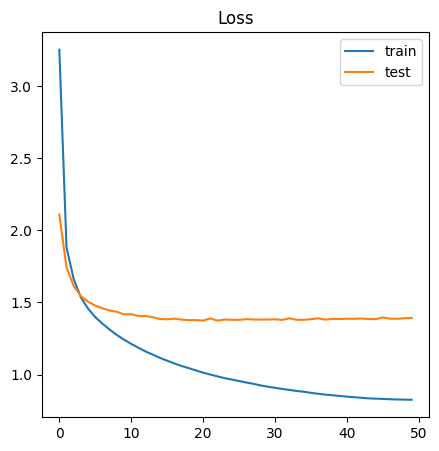

In [25]:
plot_train_process(train_loss, test_loss)

In [11]:
torch.save(model.state_dict(), '/kaggle/working/model_weights.pth')

RuntimeError: File /kaggle/input/model-efficient-and-lstm/model_weights.pth cannot be opened.

In [16]:
model = ImageCaptionModel(
    embed_size=300,
    vocab_size=30522,
    hidden_size=512,
    max_length=31
)
model.load_state_dict(torch.load("/kaggle/input/model-efficient-and-lstm/model_weights.pth", map_location=torch.device(DEVICE)))

<All keys matched successfully>

# Model: EfficientNet + transformer

In [9]:
class EfficientNetEncoder(nn.Module):
    def __init__(self, embed_dim, dropout=0.2):
        super(EfficientNetEncoder, self).__init__()
        efficientnet = models.efficientnet_b0(pretrained=True)
        self.efficientnet = efficientnet.features
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7)) # hz nujno li
        self.projection = nn.Linear(1280, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, images):
        features = self.efficientnet(images)
        features = self.adaptive_pool(features)
        
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        # features = self.dropout(features)

        embedding = self.projection(features)
        return embedding


class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, dropout=0.2):
        super(TransformerDecoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dropout=dropout,
            batch_first=True
        )

        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer=decoder_layer,
            num_layers=num_layers
        )

        self.fc_out = nn.Linear(embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.embed_dim = embed_dim

    def forward(self, features, captions):
        seq_len = captions.shape[1]
        
        captions_embed = self.embedding(captions) * (self.embed_dim ** 0.5)
        captions_embed = self.positional_encoding(captions_embed)
        captions_embed = self.dropout(captions_embed)

        tgt_mask = self.generate_square_subsequent_mask(seq_len).to(DEVICE)

        features = self.dropout(features)
        
        decoder_output = self.transformer_decoder(
            tgt=captions_embed, 
            memory=features, 
            tgt_mask=tgt_mask
        )

        output = self.fc_out(decoder_output)
        output = self.dropout(output)
        return output

    def generate_square_subsequent_mask(self, size):
        mask = torch.triu(torch.ones(size, size, dtype=torch.bool), diagonal=1)
        mask = mask.float().masked_fill(mask, float('-inf'))
        return mask


class ProdImageCaptioningModel(nn.Module):
    def __init__(self, embed_dim, vocab_size, num_heads, num_layers, processor, max_length, dropout=0.2):
        super(ProdImageCaptioningModel, self).__init__()
        self.encoder = EfficientNetEncoder(embed_dim)
        self.decoder = TransformerDecoder(
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_layers=num_layers,
            dropout=dropout
        )

        self.processor = processor
        self.max_length = max_length

    def forward(self, images, captions=None):
        if captions is None:
            return self.generate_text(images)

        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

    def generate_text(self, images):
        self.eval()
        batch_size = images.shape[0]
        
        with torch.no_grad():
            features = self.encoder(images.to(DEVICE))

        # start_token = self.processor.tokenizer.cls_token
        captions = torch.full((batch_size, 1), 101, dtype=torch.long).to(DEVICE)

        for _ in range(self.max_length - 1):
            with torch.no_grad():
                outputs = self.decoder(features, captions)
            
            last_word_logits = outputs[:, -1, :]
            predicted_ids = torch.argmax(last_word_logits, dim=-1)
            captions = torch.cat([captions, predicted_ids.unsqueeze(1)], dim=1)

            # if torch.all(predicted_ids == tokenizer.pad_token):
            if torch.all(predicted_ids == 102) or torch.all(predicted_ids == 0):
                break

        generated_texts = self.processor.tokenizer.batch_decode(captions.tolist(), skip_special_tokens=True)
        return generated_texts


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_length=5000):
        super(PositionalEncoding, self).__init__()

        pos_emb = torch.zeros(max_length, d_model)
        position = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pos_emb[:, 0::2] = torch.sin(position * div_term)
        pos_emb[:, 1::2] = torch.cos(position * div_term)
        pos_emb = pos_emb.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pos_emb', pos_emb)

    def forward(self, x):
        x = x + self.pos_emb[:x.size(0), :]
        return x

# Train better model

In [9]:
def train_model(model, train_loader, test_loader, val_loader, loss_fn, optimizer, scheduler, n_epochs, device, save=True):
    train_loss = []
    test_loss = []
    best_loss = 10000

    for epoch in tqdm(range(n_epochs)):        
        ep_train_loss = []
        ep_test_loss = []

        model.train(True)
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            decoder_inputs = y_batch[:, :-1]
            decoder_targets = y_batch[:, 1:]
            
            preds = model(X_batch, decoder_inputs)
            preds = preds.reshape(-1, preds.shape[-1])
            targets = decoder_targets.reshape(-1)
            loss = loss_fn(preds, targets)

            loss.backward()
            optimizer.step()
            scheduler.step()

            ep_train_loss.append(loss.item())

        model.train(False)
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                decoder_inputs = y_batch[:, :-1]
                decoder_targets = y_batch[:, 1:]
                
                preds = model(X_batch, decoder_inputs)
                preds = preds.reshape(-1, preds.shape[-1])
                targets = decoder_targets.reshape(-1)
                
                loss = loss_fn(preds, targets)
                ep_test_loss.append(loss.item())
    
        train_loss.append(np.mean(ep_train_loss))
        test_loss.append(np.mean(ep_test_loss))
    
        print(f"Epoch {epoch + 1} of {n_epochs}")
        print(f"\t training loss: {train_loss[-1]:.6f}")
        print(f"\t test loss: {test_loss[-1]:.6f}")

        if save and test_loss[-1] < best_loss:
            torch.save(model.state_dict(), '/kaggle/working/model_weights.pth')
            best_loss = test_loss[-1]

            with torch.no_grad():
                x_batch, y_batch = next(iter(val_loader))
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                result = model(x_batch)
                print(result)

    return train_loss, test_loss

In [19]:
first_learning_epochs = 10
second_learning_epochs = 40
warm_up_epochs = second_learning_epochs // 10

first_learning_lr = 1e-4
encoder_learning_lr = 1e-5
decoder_learning_lr = 5e-5

model = ProdImageCaptioningModel(
    embed_dim=512,
    vocab_size=30522,
    num_heads=8,
    num_layers=4,
    processor=processor,
    max_length=31
)

model.to(DEVICE)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1, ignore_index=0)

for param in model.encoder.efficientnet.parameters():
    param.requires_grad = False

first_optimizer = torch.optim.AdamW(model.parameters(), lr=first_learning_lr, weight_decay=0.01)
first_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(first_optimizer, T_max=first_learning_epochs)

first_train_loss, first_test_loss = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=first_optimizer,
    scheduler=first_scheduler,
    n_epochs=first_learning_epochs,
    device=DEVICE
)

for param in model.encoder.efficientnet.parameters():
    param.requires_grad = True

param_groups = [
    {
        "params": model.encoder.efficientnet.parameters(), 
        "lr": encoder_learning_lr
    },
    {
        "params": list(model.decoder.parameters()) + list(model.encoder.projection.parameters()),
        "lr": decoder_learning_lr
    }
]

second_optimizer = torch.optim.AdamW(param_groups, weight_decay=0.01)

warm_up_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer=second_optimizer,
    start_factor=0.05,
    total_iters=warm_up_epochs
)

cos_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer=second_optimizer,
    T_max=second_learning_epochs-warm_up_epochs
)

second_scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer=second_optimizer,
    schedulers=[warm_up_scheduler, cos_scheduler],
    milestones=[warm_up_epochs]
)

second_train_loss, second_test_loss = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=second_optimizer,
    scheduler=second_scheduler,
    n_epochs=second_learning_epochs,
    device=DEVICE
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 of 10
	 training loss: 7.120013
	 test loss: 5.484410


 10%|█         | 1/10 [01:12<10:51, 72.40s/it]

['a man in a man in a red is is is in a red is in a red is in a red is is in a red..', 'a man in a black and white dog is running in a red is running in a red is running in a red is running...', 'a man in a black and white dog is in a red is in a red is running in a red.....', 'a man in a black and white dog is running in a red and white dog is running in a red and white dog is running..']
Epoch 2 of 10
	 training loss: 6.093170
	 test loss: 5.063750


 20%|██        | 2/10 [02:23<09:33, 71.68s/it]

...

Epoch 38 of 40
	 training loss: 4.107848
	 test loss: 4.206925


 98%|█████████▊| 39/40 [1:00:52<01:33, 93.55s/it]

Epoch 39 of 40
	 training loss: 4.095434
	 test loss: 4.214473


100%|██████████| 40/40 [1:02:25<00:00, 93.65s/it]

Epoch 40 of 40
	 training loss: 4.069755
	 test loss: 4.202992


# Test model

In [12]:
def evaluate_cider(model, val_loader, processor, device, max_eval_samples=None):
    """
    Вычисляет метрику CIDEr для модели
    """
    model.eval()
    
    # Собираем предсказания и ground truth
    predictions = []
    references = []
    
    with torch.no_grad():
        for i, (images, captions) in enumerate(tqdm(val_loader)):
            if max_eval_samples and i * images.size(0) >= max_eval_samples:
                break
                
            images = images.to(device)
            
            # Генерируем предсказания
            generated_texts = model.generate_text(images)
            
            # Получаем ground truth тексты
            ground_truth_texts = processor.tokenizer.batch_decode(
                captions.tolist(), 
                skip_special_tokens=True
            )
            
            # Добавляем в списки
            for j in range(len(generated_texts)):
                predictions.append({
                    'image_id': i * images.size(0) + j,
                    'caption': generated_texts[j]
                })
                references.append({
                    'image_id': i * images.size(0) + j,
                    'caption': [ground_truth_texts[j]]  # CIDEr ожидает список captions
                })
    
    # Преобразуем в формат для CIDEr
    pred_dict = {str(p['image_id']): [p['caption']] for p in predictions}
    ref_dict = {}
    
    for ref in references:
        image_id = str(ref['image_id'])
        if image_id not in ref_dict:
            ref_dict[image_id] = []
        ref_dict[image_id].extend(ref['caption'])
    
    # Вычисляем CIDEr
    cider_evaluator = Cider()
    cider_score, _ = cider_evaluator.compute_score(ref_dict, pred_dict)
    
    return cider_score, predictions, references

In [10]:
model = ProdImageCaptioningModel(
    embed_dim=512,
    vocab_size=30522,
    num_heads=8,
    num_layers=4,
    processor=processor,
    max_length=31
)

model.load_state_dict(torch.load("/kaggle/input/model-efficientnet-transformer/model_weights.pth", map_location=torch.device(DEVICE)))

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s]


<All keys matched successfully>

In [14]:
cider_score, predictions, references = evaluate_cider(model, val_loader, processor, DEVICE)

100%|██████████| 250/250 [05:10<00:00,  1.24s/it]


In [19]:
print(predictions[0], references[0])

{'image_id': 0, 'caption': 'a girl in a red jacket and a brown jacket sitting on a bench.'} {'image_id': 0, 'caption': ['the middle eastern woman wearing the pink headscarf is walking beside a woman in a purple headscarf.']}
